### 📊 AED para explorar a Adequação de Nível (IAN)

**Base:** `df_base.parquet` — consolidação gerada no Notebook `01_AED_DF_PROCESSED.ipynb`.

❓Precisamos responder as seguintes perguntas:
- Qual é o perfil geral de defasagem dos alunos (IAN)
- e como ele evolui ao longo do ano?

#### ⚙️ Import e Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# Carregar base consolidada
df = pd.read_parquet('../../data/db/01_silver_processed/df_base.parquet')

# Confirmar se bate com os resultados obtidos durante a etapa de preparação no notebook 01_AED_DF_PROCESSED.ipynb
print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')
print(f'Anos: {sorted(df["ano"].unique())}')
print(f'Registros por ano: {df["ano"].value_counts().sort_index().to_dict()}')

df_base: 3030 linhas | 31 colunas
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
Registros por ano: {2022: 860, 2023: 1014, 2024: 1156}


#### 🔷 1. Adequação do nível (IAN):

O IAN mede se o aluno está na fase correta para sua idade/nível escolar.  
Possui apenas 3 valores e está diretamente ligado à defasagem:

| Defasagem (D) | Situação | IAN |
|---|---|---|
| D ≥ 0 | Na fase ou adiantado | 10.0 |
| −2 ≤ D < 0 | Defasagem moderada | 5.0 |
| D < −2 | Defasagem severa | 2.5 |

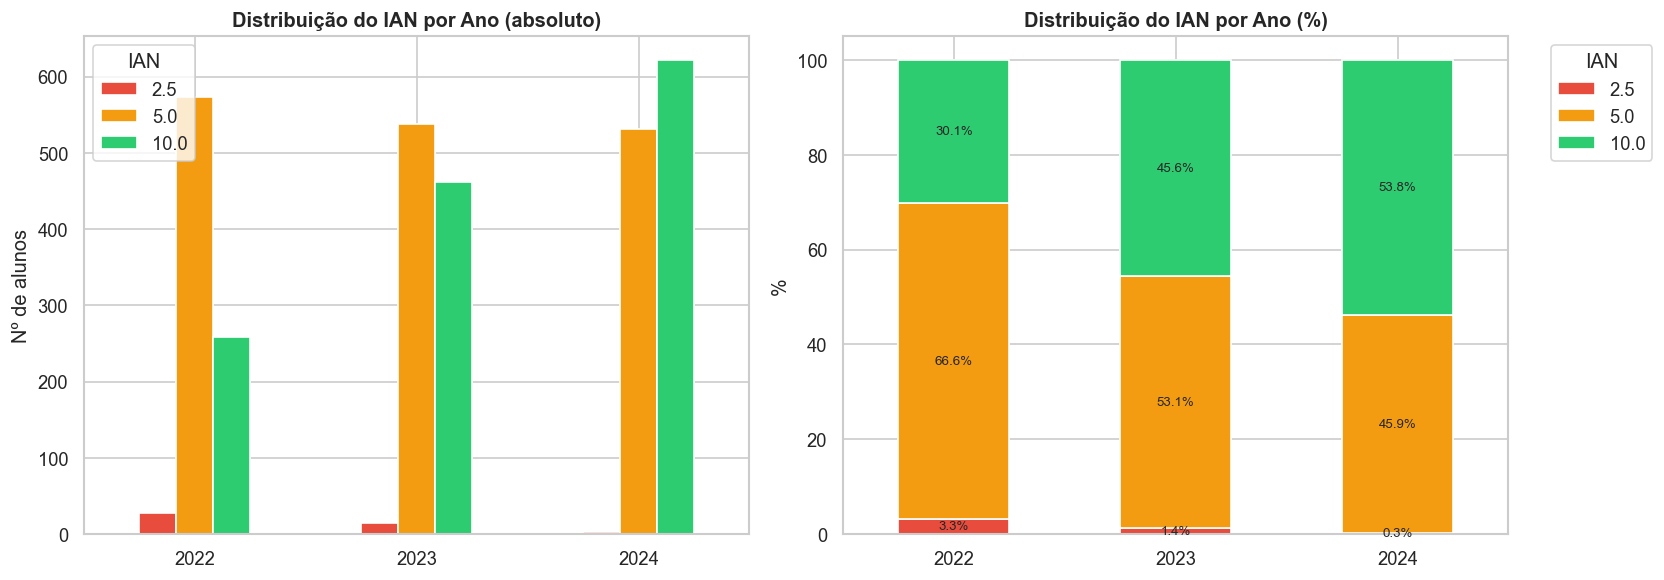


=== IAN por ano (%) ===
IAN   2.5   5.0   10.0
ano                   
2022   3.3  66.6  30.1
2023   1.4  53.1  45.6
2024   0.3  45.9  53.8


In [2]:
# Distribuição do IAN por ano
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem absoluta
ct = pd.crosstab(df['ano'], df['IAN'])
ct.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[0].set_title('Distribuição do IAN por Ano (absoluto)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nº de alunos')
axes[0].legend(title='IAN')
axes[0].tick_params(axis='x', rotation=0)

# Percentual
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[1].set_title('Distribuição do IAN por Ano (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].legend(title='IAN', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=0)

# Adicionar rótulos de % nas barras empilhadas
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

# Tabela resumo
print('\n=== IAN por ano (%) ===')
print(ct_pct.round(1).to_string())

In [3]:
# Validar se a regra documentada (IAN depende da defasagem) se confirma nos dados
df_valid = df[df['IAN'].notna() & df['defasagem'].notna()].copy()

# Regra esperada:
#   D >= 0  → IAN = 10
#   -2 <= D < 0  → IAN = 5
#   D < -2  → IAN = 2.5
def ian_esperado(d):
    if d >= 0: return 10.0
    if d >= -2: return 5.0
    return 2.5

df_valid['IAN_esperado'] = df_valid['defasagem'].apply(ian_esperado)
df_valid['regra_ok'] = df_valid['IAN'] == df_valid['IAN_esperado']

total = len(df_valid)
corretos = df_valid['regra_ok'].sum()
print(f'Regra IAN × Defasagem: {corretos}/{total} ({corretos/total*100:.1f}%) confirmados')

# Mostrar exceções (se houver)
excecoes = df_valid[~df_valid['regra_ok']]
if len(excecoes) > 0:
    print(f'\n⚠️ {len(excecoes)} exceções encontradas:')
    print(excecoes[['ano', 'RA', 'nivel', 'defasagem', 'IAN', 'IAN_esperado']].head(10))
else:
    print('✅ Nenhuma exceção — a regra é 100% consistente nos dados.')

Regra IAN × Defasagem: 3030/3030 (100.0%) confirmados
✅ Nenhuma exceção — a regra é 100% consistente nos dados.


##### 💡 Insights — IAN
- A proporção de alunos com IAN=10 (na fase correta) está aumentando ao longo dos anos: ~15% de 22 para 23 e ~8% de 23 para 24
- A regra IAN × Defasagem é 100% consistente
- O IAN=2.5 (defasagem severa) está diminuindo com o tempo: 3.3% > 1.4% > 0.3%

Alunos com dados nos 3 anos: 468

Trajetória de defasagem (2022 → 2024):
  Melhorou  :  275 (58.8%)
  Estável   :  145 (31.0%)
  Piorou    :   48 (10.3%)


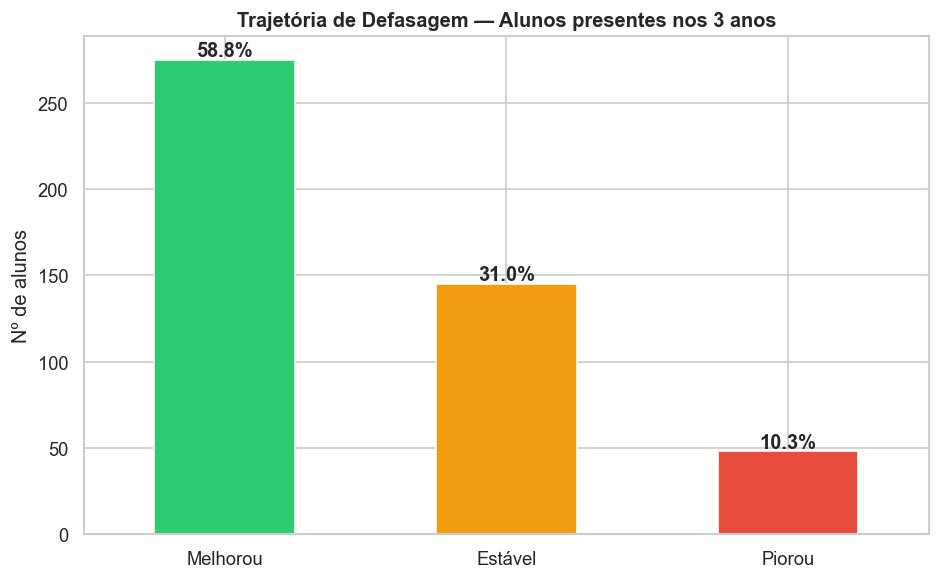

In [4]:
# Alunos presentes nos 3 anos — evolução da defasagem
alunos_3anos = df.groupby('RA').filter(lambda x: x['ano'].nunique() == 3)

print(f'Alunos com dados nos 3 anos: {alunos_3anos["RA"].nunique()}')

# Pivot: uma linha por aluno, colunas = defasagem em cada ano
pivot_defas = alunos_3anos.pivot_table(
    index='RA', columns='ano', values='defasagem', aggfunc='first'
)

# Classificar trajetória
pivot_defas['delta_22_24'] = pivot_defas[2024] - pivot_defas[2022]
pivot_defas['trajetoria'] = pivot_defas['delta_22_24'].apply(
    lambda d: 'Melhorou' if d > 0 else ('Piorou' if d < 0 else 'Estável')
)

traj = pivot_defas['trajetoria'].value_counts()
print(f'\nTrajetória de defasagem (2022 → 2024):')
for t, n in traj.items():
    pct = n / len(pivot_defas) * 100
    print(f'  {t:10}: {n:4d} ({pct:.1f}%)')

# Visualizar
fig, ax = plt.subplots(figsize=(8, 5))
cores = {'Melhorou': '#2ecc71', 'Estável': '#f39c12', 'Piorou': '#e74c3c'}
traj.plot(kind='bar', color=[cores[t] for t in traj.index], ax=ax)
ax.set_title('Trajetória de Defasagem — Alunos presentes nos 3 anos', fontweight='bold')
ax.set_ylabel('Nº de alunos')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

for i, (t, n) in enumerate(traj.items()):
    ax.text(i, n + 2, f'{n/len(pivot_defas)*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

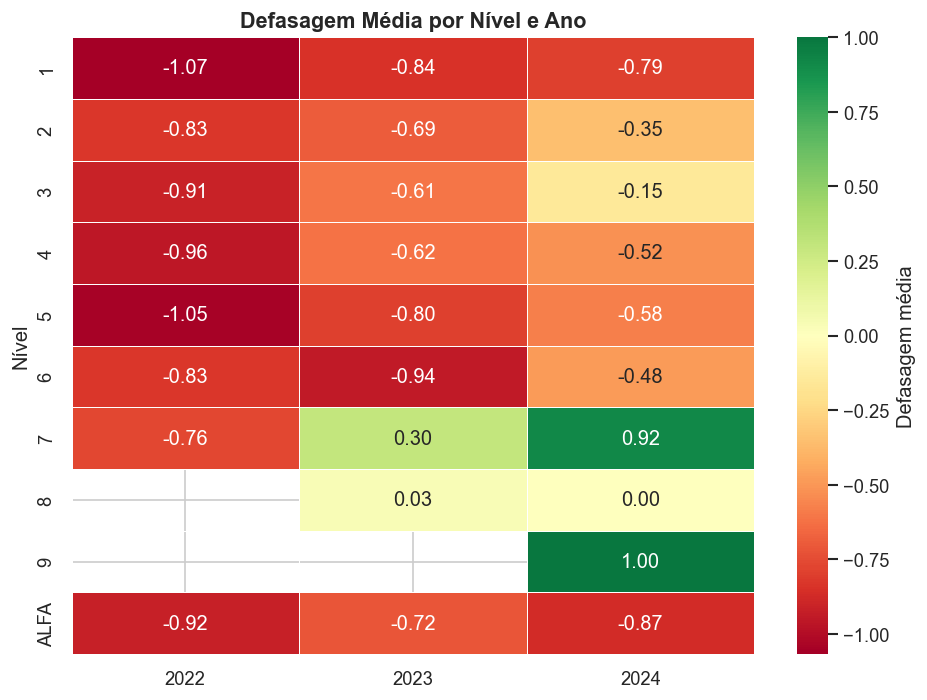

In [5]:
# Heatmap: defasagem média por nível e ano
df_hm = df[df['defasagem'].notna()].copy()

pivot_hm = df_hm.pivot_table(
    index='nivel', columns='ano', values='defasagem', aggfunc='mean'
).astype(float).sort_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot_hm, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Defasagem média'}
)
ax.set_title('Defasagem Média por Nível e Ano', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Nível')
plt.tight_layout()
plt.show()

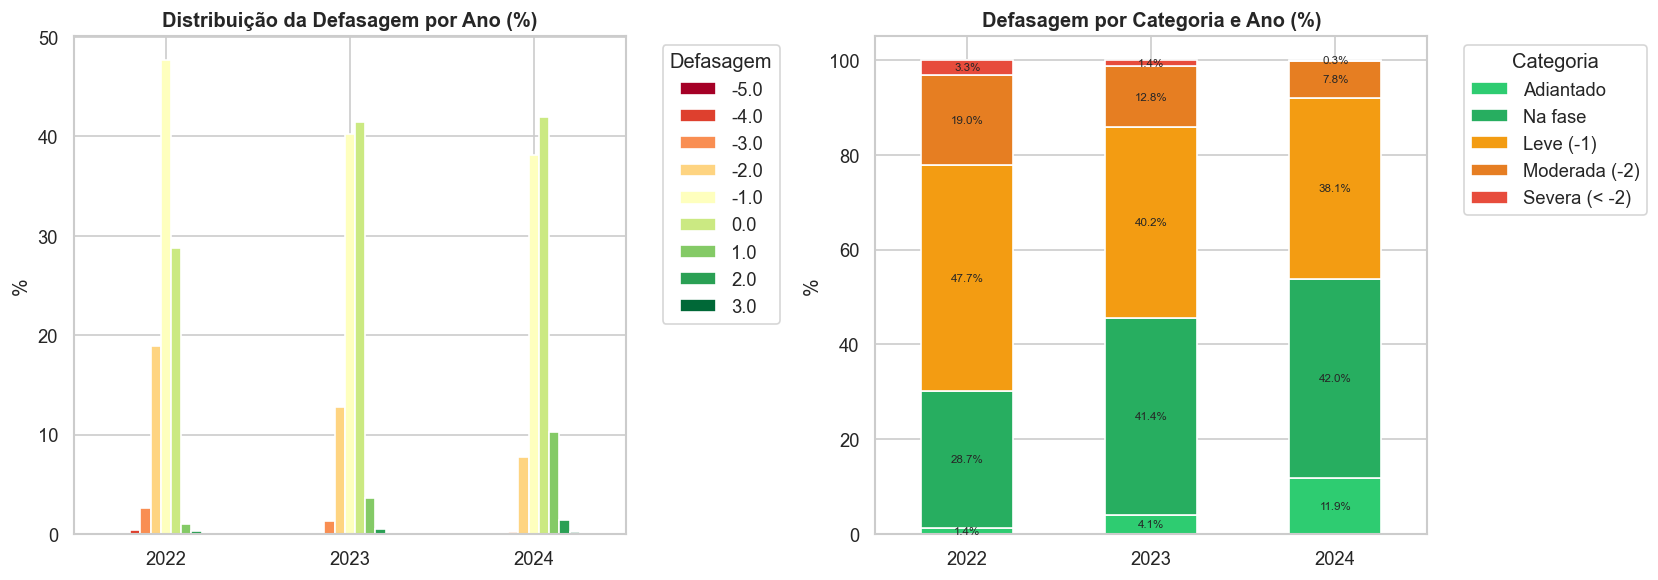

=== Defasagem por categoria e ano (%) ===
defasagem_cat  Adiantado  Na fase  Leve (-1)  Moderada (-2)  Severa (< -2)
ano                                                                       
2022                 1.4     28.7       47.7           19.0            3.3
2023                 4.1     41.4       40.2           12.8            1.4
2024                11.9     42.0       38.1            7.8            0.3

=== Totais absolutos ===
defasagem_cat  Adiantado  Na fase  Leve (-1)  Moderada (-2)  Severa (< -2)
ano                                                                       
2022                  12      247        410            163             28
2023                  42      420        408            130             14
2024                 137      485        441             90              3


In [6]:
# Perfil geral de defasagem — distribuição real dos valores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem por valor de defasagem em cada ano
ct_defas = pd.crosstab(df['ano'], df['defasagem'].astype(float))
ct_defas_pct = ct_defas.div(ct_defas.sum(axis=1), axis=0) * 100

ct_defas_pct.plot(kind='bar', ax=axes[0], colormap='RdYlGn')
axes[0].set_title('Distribuição da Defasagem por Ano (%)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')
axes[0].legend(title='Defasagem', bbox_to_anchor=(1.05, 1))
axes[0].tick_params(axis='x', rotation=0)

# Agrupar em categorias mais legíveis
def classificar_defasagem(d):
    if pd.isna(d): return np.nan
    if d > 0: return 'Adiantado'
    if d == 0: return 'Na fase'
    if d >= -1: return 'Leve (-1)'
    if d >= -2: return 'Moderada (-2)'
    return 'Severa (< -2)'

df['defasagem_cat'] = df['defasagem'].apply(classificar_defasagem)

ordem = ['Adiantado', 'Na fase', 'Leve (-1)', 'Moderada (-2)', 'Severa (< -2)']
cores = {'Adiantado': '#2ecc71', 'Na fase': '#27ae60', 'Leve (-1)': '#f39c12',
         'Moderada (-2)': '#e67e22', 'Severa (< -2)': '#e74c3c'}

ct_cat = pd.crosstab(df['ano'], df['defasagem_cat'])[ordem]
ct_cat_pct = ct_cat.div(ct_cat.sum(axis=1), axis=0) * 100

ct_cat_pct.plot(kind='bar', stacked=True, ax=axes[1],
                color=[cores[c] for c in ordem])
axes[1].set_title('Defasagem por Categoria e Ano (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].legend(title='Categoria', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=7)

plt.tight_layout()
plt.show()

# Tabela resumo
print('=== Defasagem por categoria e ano (%) ===')
print(ct_cat_pct.round(1).to_string())
print(f'\n=== Totais absolutos ===')
print(ct_cat.to_string())

In [7]:
# Perfil dos alunos com defasagem severa (D < -2) e moderada (D = -2)
df_risco = df[df['defasagem'].astype(float) <= -2].copy()

print(f'Alunos com defasagem >= -2: {len(df_risco)} registros ({len(df_risco)/len(df)*100:.1f}% do total)')
print(f'\nPor ano:')
print(df_risco['ano'].value_counts().sort_index().to_string())

print(f'\nPor nível:')
print(df_risco['nivel'].value_counts().sort_index().to_string())

# Comparar indicadores: defasagem severa vs na fase
df_comp = df[df['IAN'].notna()].copy()
df_comp['grupo'] = df_comp['IAN'].map({
    2.5: 'Severa (IAN=2.5)',
    5.0: 'Moderada (IAN=5.0)',
    10.0: 'Na fase (IAN=10.0)'
})

indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']
resumo = df_comp.groupby('grupo')[indicadores].mean().round(2)
resumo = resumo.reindex(['Severa (IAN=2.5)', 'Moderada (IAN=5.0)', 'Na fase (IAN=10.0)'])

print(f'\n=== Média dos indicadores por grupo de defasagem ===')
print(resumo.to_string())

Alunos com defasagem >= -2: 428 registros (14.1% do total)

Por ano:
ano
2022    191
2023    144
2024     93

Por nível:
nivel
1        73
2        30
3        70
4        60
5        63
6         7
ALFA    125

=== Média dos indicadores por grupo de defasagem ===
                     IDA   IEG   IAA   IPS   IPP   IPV  INDE
grupo                                                       
Severa (IAN=2.5)    4.65  7.02  7.47  5.70  6.76  6.67  5.88
Moderada (IAN=5.0)  6.24  8.10  7.86  6.30  7.03  7.44  6.97
Na fase (IAN=10.0)  6.63  7.78  8.02  6.29  7.42  7.73  7.74


In [8]:
# Evolução de TODOS os alunos com pelo menos 2 anos consecutivos de dados
# Grupo 1: presentes em 2022 e 2024 (ou 2022-2023-2024)
# Grupo 2: presentes em 2023 e 2024 (entraram em 2023)

# Pegar o primeiro e último ano de cada aluno
df_evol = df[df['IAN'].notna()].copy()

primeiro_ultimo = df_evol.groupby('RA').agg(
    primeiro_ano=('ano', 'min'),
    ultimo_ano=('ano', 'max'),
    n_anos=('ano', 'nunique')
).query('n_anos >= 2')

print(f'Alunos com pelo menos 2 anos de dados: {len(primeiro_ultimo)}')
print(f'  Desde 2022 (2022→2024): {(primeiro_ultimo["primeiro_ano"] == 2022).sum()}')
print(f'  Desde 2023 (2023→2024): {(primeiro_ultimo["primeiro_ano"] == 2023).sum()}')

# Para cada aluno, pegar IAN do primeiro e último ano
def pegar_ian_extremos(grupo):
    grupo = grupo.sort_values('ano')
    return pd.Series({
        'IAN_inicio': grupo.iloc[0]['IAN'],
        'IAN_fim': grupo.iloc[-1]['IAN'],
        'ano_inicio': grupo.iloc[0]['ano'],
        'ano_fim': grupo.iloc[-1]['ano'],
    })

evol = (df_evol[df_evol['RA'].isin(primeiro_ultimo.index)]
        .groupby('RA')
        .apply(pegar_ian_extremos)
        .reset_index())

# Classificar evolução
def classificar_evolucao(row):
    if row['IAN_inicio'] == 10 and row['IAN_fim'] == 10:
        return 'Manteve adequado'
    if row['IAN_fim'] == 10 and row['IAN_inicio'] < 10:
        return 'Recuperou (→ IAN=10)'
    if row['IAN_fim'] > row['IAN_inicio']:
        return 'Melhorou'
    if row['IAN_fim'] < row['IAN_inicio']:
        return 'Piorou'
    return 'Estável (defasado)'

evol['evolucao'] = evol.apply(classificar_evolucao, axis=1)

# Separar por coorte (desde 2022 vs desde 2023)
evol['coorte'] = evol['ano_inicio'].map({2022: 'Desde 2022', 2023: 'Desde 2023'})

# Resumo geral
print(f'\n=== Evolução geral ({len(evol)} alunos) ===')
ev_geral = evol['evolucao'].value_counts()
for e, n in ev_geral.items():
    print(f'  {e:25}: {n:4d} ({n/len(evol)*100:.1f}%)')

# Resumo por coorte
print(f'\n=== Evolução por coorte ===')
for coorte in ['Desde 2022', 'Desde 2023']:
    sub = evol[evol['coorte'] == coorte]
    print(f'\n  {coorte} ({len(sub)} alunos):')
    ev_sub = sub['evolucao'].value_counts()
    for e, n in ev_sub.items():
        print(f'    {e:25}: {n:4d} ({n/len(sub)*100:.1f}%)')

Alunos com pelo menos 2 anos de dados: 901
  Desde 2022 (2022→2024): 604
  Desde 2023 (2023→2024): 297

=== Evolução geral (901 alunos) ===
  Estável (defasado)       :  281 (31.2%)
  Manteve adequado         :  255 (28.3%)
  Recuperou (→ IAN=10)     :  243 (27.0%)
  Piorou                   :  114 (12.7%)
  Melhorou                 :    8 (0.9%)

=== Evolução por coorte ===

  Desde 2022 (604 alunos):
    Estável (defasado)       :  207 (34.3%)
    Recuperou (→ IAN=10)     :  197 (32.6%)
    Manteve adequado         :  149 (24.7%)
    Piorou                   :   45 (7.5%)
    Melhorou                 :    6 (1.0%)

  Desde 2023 (297 alunos):
    Manteve adequado         :  106 (35.7%)
    Estável (defasado)       :   74 (24.9%)
    Piorou                   :   69 (23.2%)
    Recuperou (→ IAN=10)     :   46 (15.5%)
    Melhorou                 :    2 (0.7%)


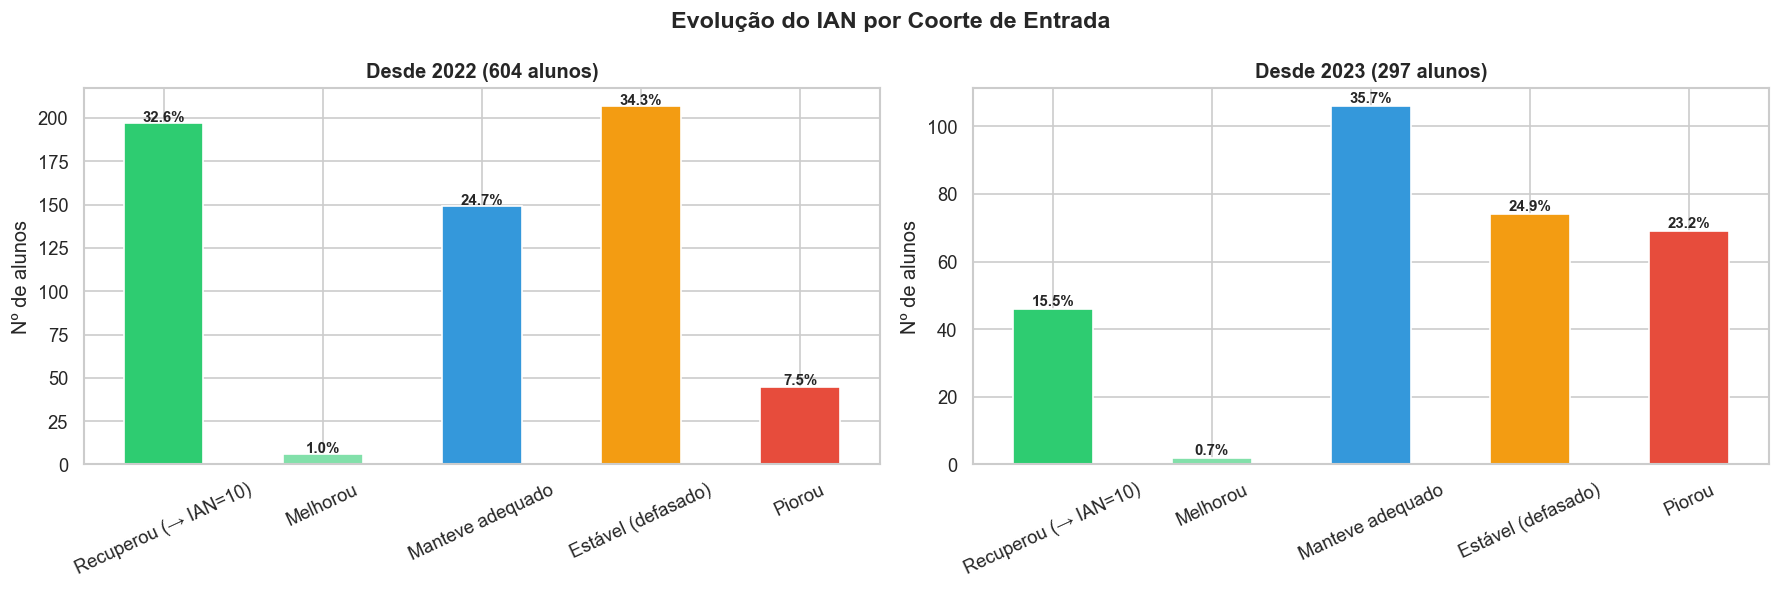

In [9]:
# Visualizar evolução por coorte lado a lado
ordem_ev = ['Recuperou (→ IAN=10)', 'Melhorou', 'Manteve adequado', 'Estável (defasado)', 'Piorou']
cores_ev = {
    'Recuperou (→ IAN=10)': '#2ecc71',
    'Melhorou': '#82e0aa',
    'Manteve adequado': '#3498db',
    'Estável (defasado)': '#f39c12',
    'Piorou': '#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, coorte in enumerate(['Desde 2022', 'Desde 2023']):
    sub = evol[evol['coorte'] == coorte]
    ev_sub = sub['evolucao'].value_counts().reindex(ordem_ev).dropna()
    
    bars = ev_sub.plot(kind='bar', ax=axes[i],
                       color=[cores_ev[e] for e in ev_sub.index])
    axes[i].set_title(f'{coorte} ({len(sub)} alunos)', fontweight='bold')
    axes[i].set_ylabel('Nº de alunos')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=25)
    
    for j, (e, n) in enumerate(ev_sub.items()):
        axes[i].text(j, n + 1, f'{n/len(sub)*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Evolução do IAN por Coorte de Entrada', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== Defasagem por gênero e ano (%) ===
defasagem_cat   Adiantado  Na fase  Leve (-1)  Moderada (-2)  Severa (< -2)
ano  genero                                                                
2022 Feminino         2.0     29.1       48.4           17.5            3.1
     Masculino        0.7     28.3       46.9           20.6            3.5
2023 Feminino         5.1     45.1       37.0           11.5            1.3
     Masculino        3.0     37.2       44.0           14.3            1.5
2024 Feminino        10.8     45.3       37.2            6.4            0.3
     Masculino       13.1     38.1       39.2            9.4            0.2

=== IAN médio por gênero e ano ===
genero  Feminino  Masculino
ano                        
2022        6.48       6.36
2023        7.48       6.97
2024        7.79       7.56


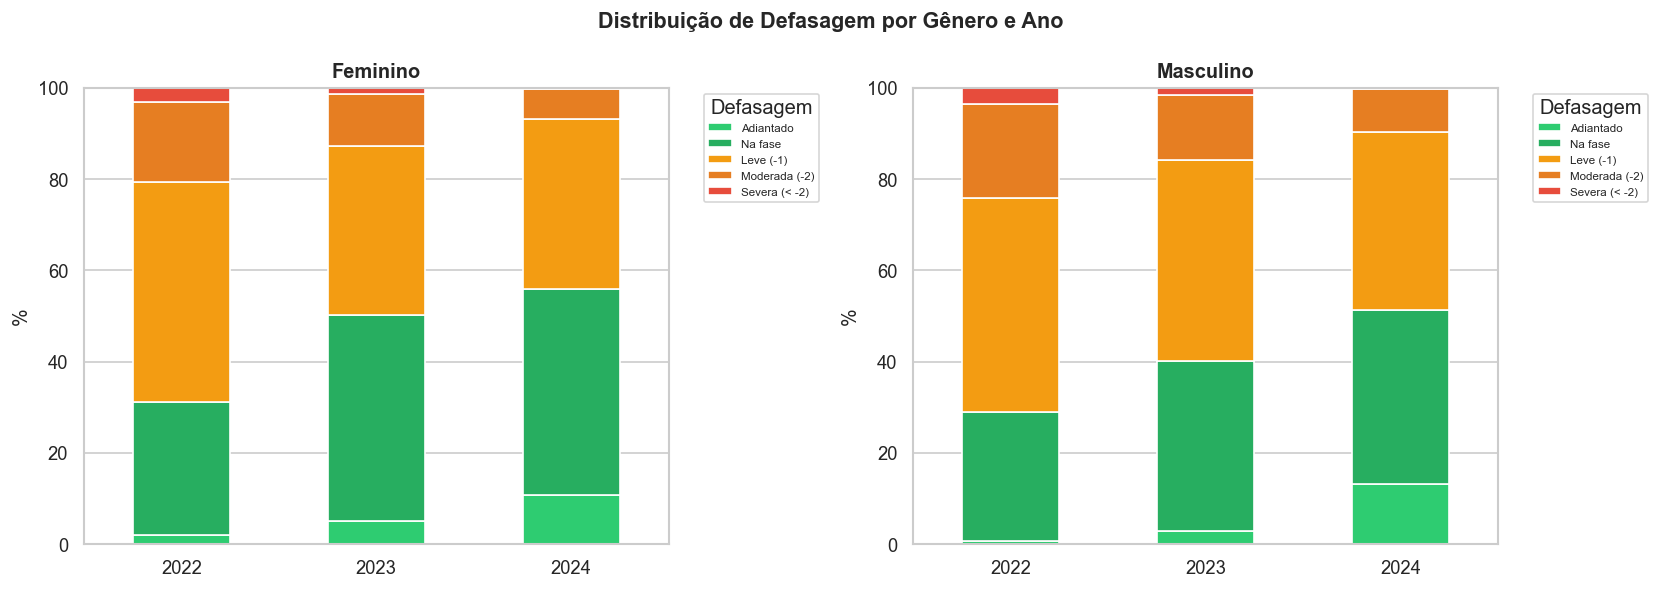

In [10]:
# Defasagem por gênero
df_gen = df[df['defasagem'].notna() & df['genero'].notna()].copy()

# Tabela cruzada: categoria de defasagem por gênero e ano
ct_gen = pd.crosstab(
    [df_gen['ano'], df_gen['genero']], 
    df_gen['defasagem_cat'], 
    normalize='index'
) * 100

ct_gen = ct_gen[['Adiantado', 'Na fase', 'Leve (-1)', 'Moderada (-2)', 'Severa (< -2)']]

print('=== Defasagem por gênero e ano (%) ===')
print(ct_gen.round(1).to_string())

# IAN médio por gênero e ano
print('\n=== IAN médio por gênero e ano ===')
print(df_gen.pivot_table(index='ano', columns='genero', values='IAN', aggfunc='mean').round(2).to_string())

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, genero in enumerate(['Feminino', 'Masculino']):
    sub = ct_gen.xs(genero, level='genero')
    sub.plot(kind='bar', stacked=True, ax=axes[i],
             color=['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c'])
    axes[i].set_title(f'{genero}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('%')
    axes[i].legend(title='Defasagem', fontsize=7, bbox_to_anchor=(1.05, 1))
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].set_ylim(0, 100)

plt.suptitle('Distribuição de Defasagem por Gênero e Ano', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== IAN médio por tipo de escola e ano ===
ano                         2022   2023   2024
tipo_escola                                   
Outros                       NaN   5.56   9.05
Privada (apadrinhamento)     NaN   8.30   9.48
Privada (bolsa 100%)         NaN   9.92  10.00
Privada (empresa parceira)   NaN  10.00  10.00
Privada (geral)              NaN   7.32   9.21
Pública                     6.23   6.90   7.21
Rede Decisão                7.78    NaN    NaN

=== Contagem por tipo de escola e ano ===
ano                         2022  2023  2024
tipo_escola                                 
Outros                         0     9    21
Privada (apadrinhamento)       0   100    96
Privada (bolsa 100%)           0    60    41
Privada (empresa parceira)     0     8     9
Privada (geral)                0    28    76
Pública                      754   809   913
Rede Decisão                 106     0     0


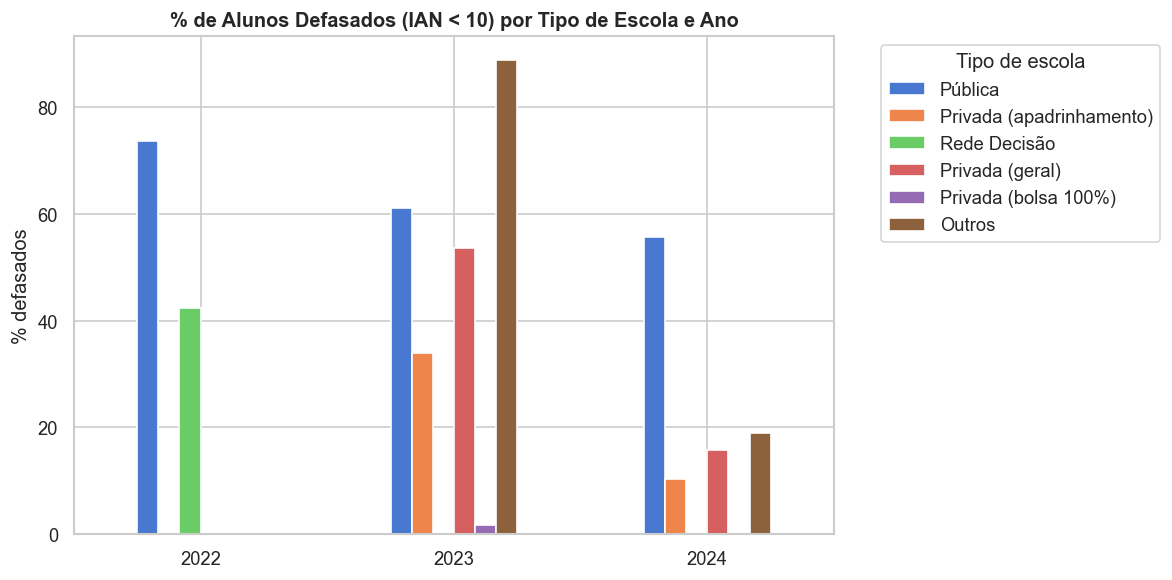

In [11]:
# Padronizar nomes de instituição (Escola Pública e Pública são a mesma coisa)
df['instituicao_pad'] = df['instituicao'].replace({
    'Escola Pública': 'Pública',
    'Escola JP II': 'Pública',
    'Privada - Programa de apadrinhamento': 'Privada - Programa de Apadrinhamento',
})

# Agrupar categorias menores
mapa_tipo = {
    'Pública': 'Pública',
    'Privada': 'Privada (geral)',
    'Privada - Programa de Apadrinhamento': 'Privada (apadrinhamento)',
    'Privada *Parcerias com Bolsa 100%': 'Privada (bolsa 100%)',
    'Privada - Pagamento por *Empresa Parceira': 'Privada (empresa parceira)',
    'Rede Decisão': 'Rede Decisão',
}
df['tipo_escola'] = df['instituicao_pad'].map(mapa_tipo).fillna('Outros')

# IAN médio por tipo de escola e ano
pivot_escola = df[df['IAN'].notna()].pivot_table(
    index='tipo_escola', columns='ano', values='IAN', aggfunc=['mean', 'count']
)

print('=== IAN médio por tipo de escola e ano ===')
print(pivot_escola['mean'].round(2).to_string())
print('\n=== Contagem por tipo de escola e ano ===')
print(pivot_escola['count'].fillna(0).astype(int).to_string())

# % defasados por tipo de escola (todos os anos)
fig, ax = plt.subplots(figsize=(10, 5))

pct_por_tipo = df[df['IAN'].notna()].groupby(['ano', 'tipo_escola']).apply(
    lambda g: (g['IAN'] < 10).mean() * 100
).unstack('tipo_escola')

# Só tipos com pelo menos 30 registros
tipos_validos = df['tipo_escola'].value_counts()
tipos_validos = tipos_validos[tipos_validos >= 30].index
pct_por_tipo = pct_por_tipo[tipos_validos.intersection(pct_por_tipo.columns)]

pct_por_tipo.plot(kind='bar', ax=ax)
ax.set_title('% de Alunos Defasados (IAN < 10) por Tipo de Escola e Ano', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% defasados')
ax.legend(title='Tipo de escola', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### O que antecede a piora na defasagem?

Até aqui analisamos quem está defasado e como a defasagem evolui. Agora vamos investigar o caminho inverso: dado que um aluno **piorou** (era adequado e ficou defasado), quais indicadores já mostravam sinais no ano anterior?

=== Transições de defasagem ===
  Manteve defasado    :  531 (38.8%)
  Manteve adequado    :  416 (30.4%)
  Recuperou           :  278 (20.3%)
  Piorou              :  144 (10.5%)

=== Indicadores do ano ANTERIOR: Piorou (n=144) vs Manteve adequado (n=416) ===
 Indicador     Piorou    Manteve       Diff
---------------------------------------------
       IDA       6.63       7.02      -0.39
       IEG       8.70       8.94      -0.24
       IAA       7.84       7.65      +0.19
       IPS       6.33       5.43      +0.90
       IPP       6.55       7.58      -1.03
       IPV       7.61       8.16      -0.55


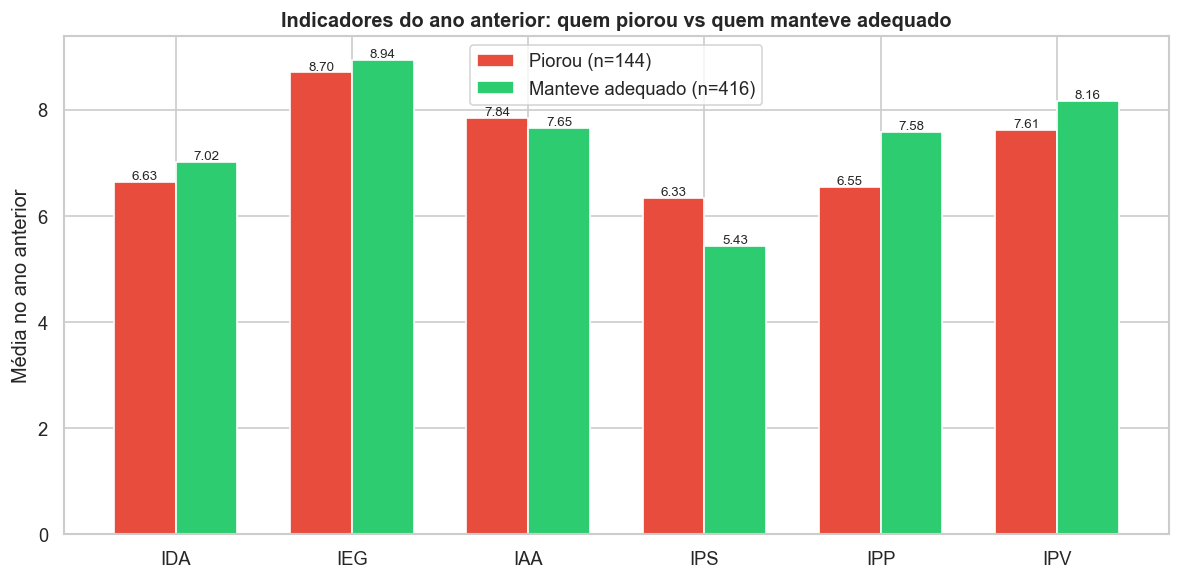

In [12]:
# Identificar alunos que mudaram de status entre anos
# Foco: adequados que ficaram defasados (pioraram) vs adequados que mantiveram (estáveis)
df_trans = df[df['IAN'].notna()].copy()

pares = []
for ra, grupo in df_trans.groupby('RA'):
    grupo = grupo.sort_values('ano')
    for i in range(len(grupo) - 1):
        atual = grupo.iloc[i]
        proximo = grupo.iloc[i + 1]
        pares.append({
            'RA': ra,
            'ano_atual': atual['ano'],
            'IAN_atual': atual['IAN'],
            'IAN_proximo': proximo['IAN'],
            'IDA': atual['IDA'],
            'IEG': atual['IEG'],
            'IAA': atual['IAA'],
            'IPS': atual['IPS'],
            'IPP': atual['IPP'],
            'IPV': atual['IPV'],
            'nivel': atual['nivel'],
            'pedra': atual['pedra'],
        })

df_pares = pd.DataFrame(pares)

# Classificar transição
df_pares['adequado_atual'] = df_pares['IAN_atual'] == 10
df_pares['adequado_proximo'] = df_pares['IAN_proximo'] == 10

df_pares['transicao'] = 'Outro'
df_pares.loc[df_pares['adequado_atual'] & df_pares['adequado_proximo'], 'transicao'] = 'Manteve adequado'
df_pares.loc[df_pares['adequado_atual'] & ~df_pares['adequado_proximo'], 'transicao'] = 'Piorou'
df_pares.loc[~df_pares['adequado_atual'] & df_pares['adequado_proximo'], 'transicao'] = 'Recuperou'
df_pares.loc[~df_pares['adequado_atual'] & ~df_pares['adequado_proximo'], 'transicao'] = 'Manteve defasado'

print('=== Transições de defasagem ===')
trans_ct = df_pares['transicao'].value_counts()
for t, n in trans_ct.items():
    print(f'  {t:20}: {n:4d} ({n/len(df_pares)*100:.1f}%)')

# Foco: Piorou vs Manteve adequado — o que diferencia?
piorou = df_pares[df_pares['transicao'] == 'Piorou']
manteve = df_pares[df_pares['transicao'] == 'Manteve adequado']

indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']

print(f'\n=== Indicadores do ano ANTERIOR: Piorou (n={len(piorou)}) vs Manteve adequado (n={len(manteve)}) ===')
print(f'{"Indicador":>10} {"Piorou":>10} {"Manteve":>10} {"Diff":>10}')
print('-' * 45)
for ind in indicadores:
    media_piorou = piorou[ind].mean()
    media_manteve = manteve[ind].mean()
    diff = media_piorou - media_manteve
    print(f'{ind:>10} {media_piorou:>10.2f} {media_manteve:>10.2f} {diff:>+10.2f}')

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(indicadores))
width = 0.35

vals_piorou = [piorou[ind].mean() for ind in indicadores]
vals_manteve = [manteve[ind].mean() for ind in indicadores]

bars1 = ax.bar(x - width/2, vals_piorou, width, label=f'Piorou (n={len(piorou)})', color='#e74c3c')
bars2 = ax.bar(x + width/2, vals_manteve, width, label=f'Manteve adequado (n={len(manteve)})', color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(indicadores)
ax.set_ylabel('Média no ano anterior')
ax.set_title('Indicadores do ano anterior: quem piorou vs quem manteve adequado', fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

##### 💡 Insights

**144 alunos (10.5%) que eram adequados ficaram defasados no ano seguinte**

**Os indicadores que mais sinalizavam no ano anterior:**
- **IPP é o maior diferenciador** (-1.03): quem piorou tinha 6.55 vs 7.58 de quem manteve — a avaliação psicopedagógica já detectava fragilidade um ano antes
- **IPV** (-0.55): ponto de virada mais baixo
- **IDA** (-0.39): desempenho acadêmico levemente pior
- **IEG** (-0.24): engajamento levemente pior

**IAA levemente invertido (+0.19):** quem piorou se avaliava melhor — coerente com a superestimação como sinal de risco (Pilar 4)

**IPS invertido (+0.90):** provavelmente artefato da mudança de escala entre anos, não efeito real

❓ Esses alunos que pioraram vinham de quais níveis e pedras?

In [13]:
# De qual nível e pedra vieram os que pioraram?
print('=== Pioraram: de qual nível vieram? ===')
nivel_piorou = piorou['nivel'].value_counts().sort_index()
nivel_manteve = manteve['nivel'].value_counts().sort_index()

todos_niveis = sorted(set(nivel_piorou.index) | set(nivel_manteve.index), 
                       key=lambda x: (-1, 0) if x == 'ALFA' else (0, int(x)) if str(x).isdigit() else (1, x))

print(f'{"Nível":>10} {"Piorou":>10} {"% Piorou":>10} {"Manteve":>10} {"% Manteve":>10}')
print('-' * 55)
for nivel in todos_niveis:
    n_p = nivel_piorou.get(nivel, 0)
    n_m = nivel_manteve.get(nivel, 0)
    pct_p = n_p / len(piorou) * 100 if len(piorou) > 0 else 0
    pct_m = n_m / len(manteve) * 100 if len(manteve) > 0 else 0
    print(f'{str(nivel):>10} {n_p:>10} {pct_p:>9.1f}% {n_m:>10} {pct_m:>9.1f}%')

# Pedra
print(f'\n=== Pioraram: de qual pedra vieram? ===')
pedra_piorou = piorou['pedra'].value_counts()
pedra_manteve = manteve['pedra'].value_counts()

for pedra in ['Quartzo', 'Ágata', 'Ametista', 'Topázio']:
    n_p = pedra_piorou.get(pedra, 0)
    n_m = pedra_manteve.get(pedra, 0)
    pct_p = n_p / len(piorou) * 100 if len(piorou) > 0 else 0
    pct_m = n_m / len(manteve) * 100 if len(manteve) > 0 else 0
    print(f'  {pedra:10}: Piorou={n_p} ({pct_p:.1f}%), Manteve={n_m} ({pct_m:.1f}%)')

=== Pioraram: de qual nível vieram? ===
     Nível     Piorou   % Piorou    Manteve  % Manteve
-------------------------------------------------------
      ALFA         78      54.2%         57      13.7%
         1         29      20.1%         25       6.0%
         2         13       9.0%         82      19.7%
         3         12       8.3%         87      20.9%
         4          5       3.5%         52      12.5%
         5          7       4.9%         28       6.7%
         6          0       0.0%          8       1.9%
         7          0       0.0%         18       4.3%
         8          0       0.0%         59      14.2%

=== Pioraram: de qual pedra vieram? ===
  Quartzo   : Piorou=7 (4.9%), Manteve=1 (0.2%)
  Ágata     : Piorou=24 (16.7%), Manteve=32 (7.7%)
  Ametista  : Piorou=59 (41.0%), Manteve=157 (37.7%)
  Topázio   : Piorou=54 (37.5%), Manteve=156 (37.5%)


##### 💡 Insights

**A piora é concentrada nos níveis iniciais:**
- **ALFA + Nível 1 = 74.3%** de todas as pioras — a transição dos níveis básicos para o ensino regular é onde a defasagem aparece
- ALFA sozinho representa 54.2% dos que pioraram, contra apenas 13.7% dos que mantiveram adequado
- A partir do nível 3, praticamente ninguém que era adequado piora (níveis 6-8: zero pioras)

**A piora não é um fenômeno de pedra — é de nível:**
- Nas pedras, a distribuição é proporcional (Ametista ~40%, Topázio ~37% em ambos os grupos)
- A pedra não diferencia quem piora de quem mantém — o nível sim

**💡 Para o modelo de ML:** o `nivel` (especialmente ALFA e 1) é uma feature crítica para prever risco de piora na defasagem. A transição ALFA → nível regular merece atenção especial como período de vulnerabilidade

### ⭐️ Insight final

**Qual é o perfil geral da defasagem?:**
- Em 2024, 53.9% dos alunos estão na fase ou adiantados, 38.1% com defasagem leve (-1), 7.8% moderada (-2) e apenas 0.3% severa
- A defasagem severa caiu de 3.3% (2022) → 1.4% (2023) → 0.3% (2024)
- 428 registros (14.1%) apresentam defasagem ≥ -2, concentrados nos níveis 1, 3, 4 e 5

**Como ele evolui ao longo do ano?:**
- Dos 901 alunos com pelo menos 2 anos de dados, 27.0% recuperaram completamente e 28.3% se mantiveram adequados
- Alunos com defasagem severa têm indicadores significativamente menores em todos os pilares (IDA 4.65 vs 6.63 dos adequados)

**Gênero:**
- Meninas têm IAN consistentemente maior que meninos (diferença de ~0.2 pontos)
- A diferença é pequena mas persistente: meninos apresentam proporcionalmente mais defasagem moderada

**Instituição de ensino:**
- Alunos de escola pública têm 55.6% de defasagem em 2024 — contra 15.8% das privadas e 0% das bolsas integrais
  - Aqui fica claro que: mais suporte -> menos defasagem

**Comparação entre coortes:**
- **Desde 2022 (604 alunos):** 32.6% recuperaram, apenas 7.5% pioraram — o programa tem impacto claro ao longo do tempo
- **Desde 2023 (297 alunos):** 15.5% recuperaram, mas 23.2% pioraram — o primeiro ano parece ser o período de maior risco

**O que antecede a piora na defasagem?:**
- 144 alunos (10.5%) que eram adequados ficaram defasados no ano seguinte
- **IPP é o indicador que mais sinalizava** no ano anterior (-1.03 vs quem manteve adequado), seguido de IPV (-0.55) e IDA (-0.39)
- IAA levemente invertido (+0.19): quem piorou se avaliava melhor — superestimação como sinal de risco
- **74.3% dos que pioraram vieram do ALFA ou Nível 1** — a transição dos níveis básicos para o ensino regular é o momento de maior vulnerabilidade
- A partir do nível 3, praticamente ninguém que era adequado piora

⚠️ **Implicação para o modelo de ML:**
- Alunos no primeiro ano de programa merecem atenção especial como grupo de risco
- Tipo de escola é um preditor forte de defasagem e deve ser feature no modelo
- Alunos de escola pública no primeiro ano são o grupo de maior risco
- `nivel` (especialmente ALFA e 1) é feature crítica — a transição para o ensino regular é onde a defasagem aparece
- IPP baixo em aluno adequado é sinal precoce de piora futura — a avaliação psicopedagógica já detecta fragilidade um ano antes

### Exportacao da base analitica para o Streamlit
Ao final da analise, exportamos uma base analitica enriquecida do IAN para ser consumida diretamente pela aplicacao.


In [14]:
# EXPORTAR BASE ANALITICA DO IAN PARA O STREAMLIT
from pathlib import Path
import sys

# Usa o caminho conhecido do app a partir dos notebooks de AED.
caminho_app = Path('../../app').resolve()
if str(caminho_app) not in sys.path:
    sys.path.append(str(caminho_app))

from analise_exploratoria.analiticos.ian import exportar_base_analitica_ian

# Gera o parquet analitico que a aba IAN do Streamlit passa a consumir.
caminho_saida = exportar_base_analitica_ian(df)
print(f'Base analitica do IAN exportada para: {caminho_saida}')


2026-03-22 12:59:40.003 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 12:59:40.005 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 12:59:40.005 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 12:59:40.006 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 12:59:40.006 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 12:59:40.007 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 12:59:40.007 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


Base analitica do IAN exportada para: /Users/hgirardi/Documents/Dev/pessoal/Pos_Tech_DTAT/Fase_5/Datathon/data/db/02_gold_analytics/ian_analitico.parquet


In [15]:
# Le o artefato gerado para validar rapidamente a exportacao no proprio notebook.
ian_parquet = pd.read_parquet(caminho_saida)


In [16]:
# Exibe as colunas finais para conferir o contrato usado pela aba do Streamlit.
ian_parquet.columns


Index(['ano', 'RA', 'nome', 'genero', 'idade', 'ano_ingresso', 'instituicao',
       'fase', 'turma', 'nivel', 'fase_ideal', 'defasagem', 'pedra', 'INDE',
       'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'mat', 'por', 'ing',
       'indicado_bolsa', 'atingiu_pv', 'rec_psicologia', 'pedra_20',
       'pedra_21', 'pedra_22', 'pedra_23', 'defasagem_cat', 'instituicao_pad',
       'tipo_escola', 'nivel_label', 'nivel_ordem', 'tipo_escola_macro',
       'status_ian', 'grupo_ian', 'em_defasagem', 'registro_coorte',
       'coorte_ian', 'evolucao_ian', 'IAN_inicio', 'IAN_fim', 'ano_inicio_ian',
       'ano_fim_ian', 'n_anos_ian', 'ano_proximo', 'IAN_proximo',
       'IDA_proximo', 'IEG_proximo', 'IAA_proximo', 'IPS_proximo',
       'IPP_proximo', 'IPV_proximo', 'INDE_proximo', 'nivel_label_proximo',
       'nivel_ordem_proximo', 'tipo_escola_macro_proximo',
       'status_ian_proximo', 'grupo_ian_proximo', 'em_defasagem_proximo',
       'transicao_ian'],
      dtype='object')